# Initial Dataset Graphs

- Comparison of population data by age and race for Western Cape, Gauteng and National
- We use 2022 Census data, 2011 Census data, 2025, 2024 and 2022 mid-year estimates (Stats SA) and the synthetic populations from Joubert 2018 and 2022

The table shows which datasets use which census as a baseline:

|  | Census 2011 | Census 2022 |
| -------- | -------- | -------- |
| 2025 mid year Stats SA|   |  X  |
| 2024 mid year Stats SA|   | X | 
| 2022 mid year Stats SA| X |  |
| Joubert 2018   | X |     |
| Joubert 2022   |    | X  |


NB - Joubert 2018 synthetic population is only generated for 9 urban areas in South Africa, whereas Joubert 2022 is for the whole nation. 
  

NB the National treasury (from either MERO or PERO) data hasn't been included, as they bucket their age groups 1-14, 15-64 and 64+. In the 2025 PERO report, they reference the StatSA midyear figures for age bucketed every 5 years in the WC (see figure 3.10).

- UCT-SAMRC data (used for comparison in Moultrie and Dorrington 2024) was not clearly referenced and dataset wasn't available online (link threw an error)
- NT/PERO data doesn't have granular age buckets, only 0-14, 15-64, 65+. They use the 2022 census data as a baseline too


In [1]:
import os
import xml.etree.ElementTree as ET
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import math
import gc
import io

### Read in datasets
We have:
- Age and sex for South Africa
- Age for Western Cape
- Age for Gauteng

- Race for South Africa
- Race for Western Cape
- Race for Gauteng

From the following datasets:
 - 2022 Census (Stats SA)
 - 2011 Census (Stats SA)
 - 2025 mid year projections (Stats SA)
 - 2024 mid year projections (Stats SA)
 - 2022 mid year projections (Stats SA)
 - 2018 synthetic population of urban areas (Joubert)
 - 2022 synthetic population of South Africa (Joubert)


In [2]:
# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% 
# Read in age and sex for SA
df_age_SA = pd.read_excel("Data/age_sex_SA.xlsx", sheet_name=0)

df_age_SA['Data Source'] = df_age_SA['Data Source'].ffill()

# Standardise the 80+ bucket
df_age_SA['80+'] = df_age_SA['80–84'].fillna(0) + df_age_SA['85+'].fillna(0)

df_totals_age_SA = df_age_SA[df_age_SA['Sex'] == 'Total'].copy()


# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# Read in age for WC
df_WC_age = pd.read_excel("Data/age_sex_SA.xlsx", sheet_name=1)

df_WC_age['80+'] = df_WC_age['80–84'].fillna(0) + df_WC_age['85+'].fillna(0)

df_numbers_WC = df_WC_age[~df_WC_age['Demographic'].str.contains('percentages', na=False)
].copy()

age_columns = ['00–04', '05–09', '10–14', '15–19', '20–24', '25–29', '30–34', 
               '35–39', '40–44', '45–49', '50–54', '55–59', '60–64', '65–69', 
               '70–74', '75–79', '80+']

df_numbers_WC[age_columns] = df_numbers_WC[age_columns].astype(int)


# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# Read in age for GP
df_GP_age = pd.read_excel("Data/age_sex_SA.xlsx", sheet_name=2)

df_GP_age['80+'] = df_GP_age['80–84'].fillna(0) + df_GP_age['85+'].fillna(0)

df_numbers_GP = df_GP_age[~df_GP_age['Demographic'].str.contains('percentages', na=False)
].copy()

age_columns = ['00–04', '05–09', '10–14', '15–19', '20–24', '25–29', '30–34', 
               '35–39', '40–44', '45–49', '50–54', '55–59', '60–64', '65–69', 
               '70–74', '75–79', '80+']

df_numbers_GP[age_columns] = df_numbers_GP[age_columns].round(0).astype(int)


In [3]:
# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# Read in Race for SA
df_race_SA = pd.read_excel("Data/race_percentages.xlsx", sheet_name=0)

if 'Data Source' in df_race_SA.columns:
    df_race_SA['Data Source'] = df_race_SA['Data Source'].ffill()


# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# Read in Race for WC
df_race_WC = pd.read_excel("Data/race_percentages.xlsx", sheet_name=1)

if 'Data Source' in df_race_WC.columns:
    df_race_WC['Data Source'] = df_race_WC['Data Source'].ffill()


# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# Read in Population Group (Race) for GP
df_race_GP = pd.read_excel("Data/race_percentages.xlsx", sheet_name=2)

if 'Data Source' in df_race_GP.columns:
    df_race_GP['Data Source'] = df_race_GP['Data Source'].ffill()


### Graphs

In [4]:
colour_map = {
    # CENSUS 
    '2011 Census': '#214486',   
    '2022 Census': '#6093BC',   

    # MID-YEAR ESTIMATES
    '2022 Stats SA': '#F29D5D',  
    '2024 Stats SA': '#D96D31',  
    '2025 Stats SA': '#BD4922', 

    # JOUBERT 
    '2018 Joubert': '#2F6330',         
    '2022 Joubert': '#66A867'}


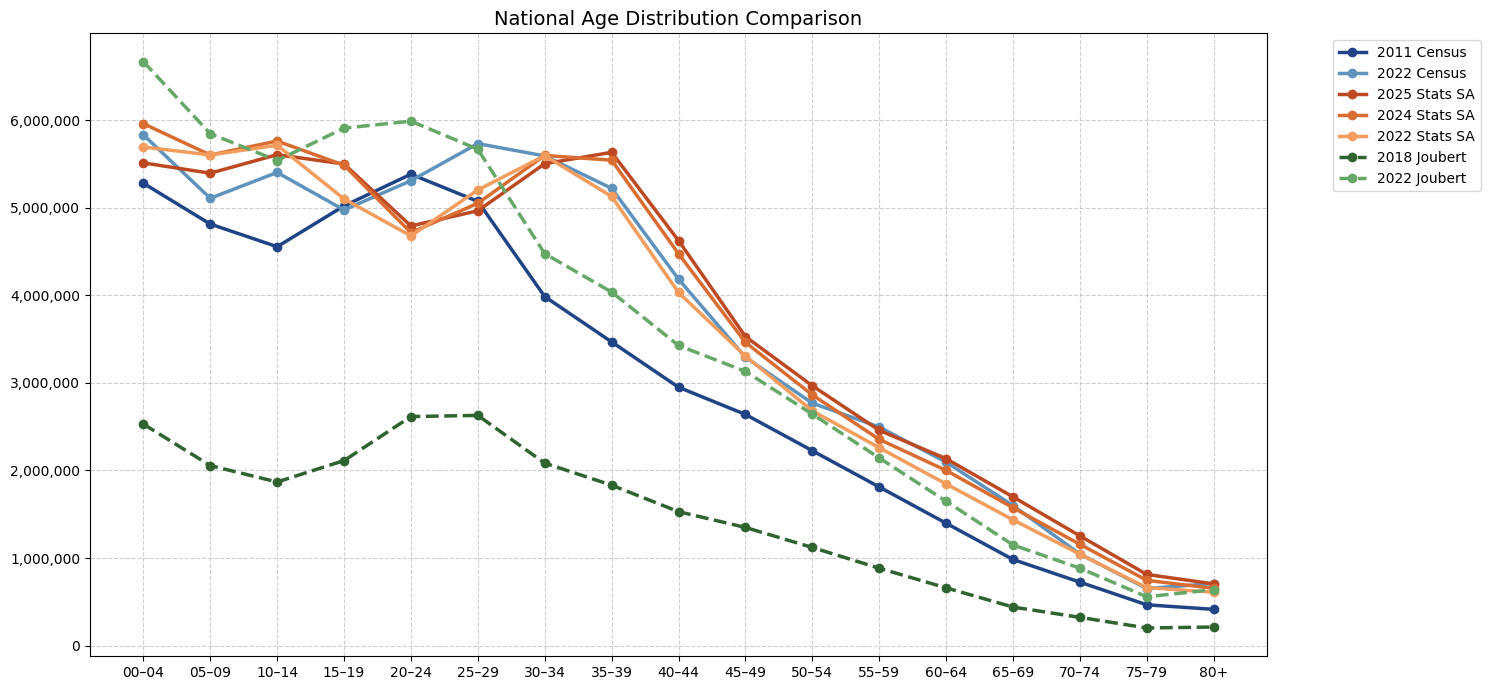

In [5]:
plt.figure(figsize=(15, 7))

for _, row in df_totals_age_SA.iterrows():
    label = str(row['Data Source']).strip()
    
    line_color = colour_map.get(label, '#95a5a6')
    
    lstyle = '--' if 'Joubert' in label else '-'
    
    plt.plot(age_columns, row[age_columns], 
             label=label, 
             color=line_color, 
             marker='o', 
             linewidth=2.5,
             linestyle=lstyle)

# Formatting
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.title('National Age Distribution Comparison', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

#plt.savefig("Graphs/National_age_distribution_comparisons.pdf", dpi=300, bbox_inches='tight')
plt.show()

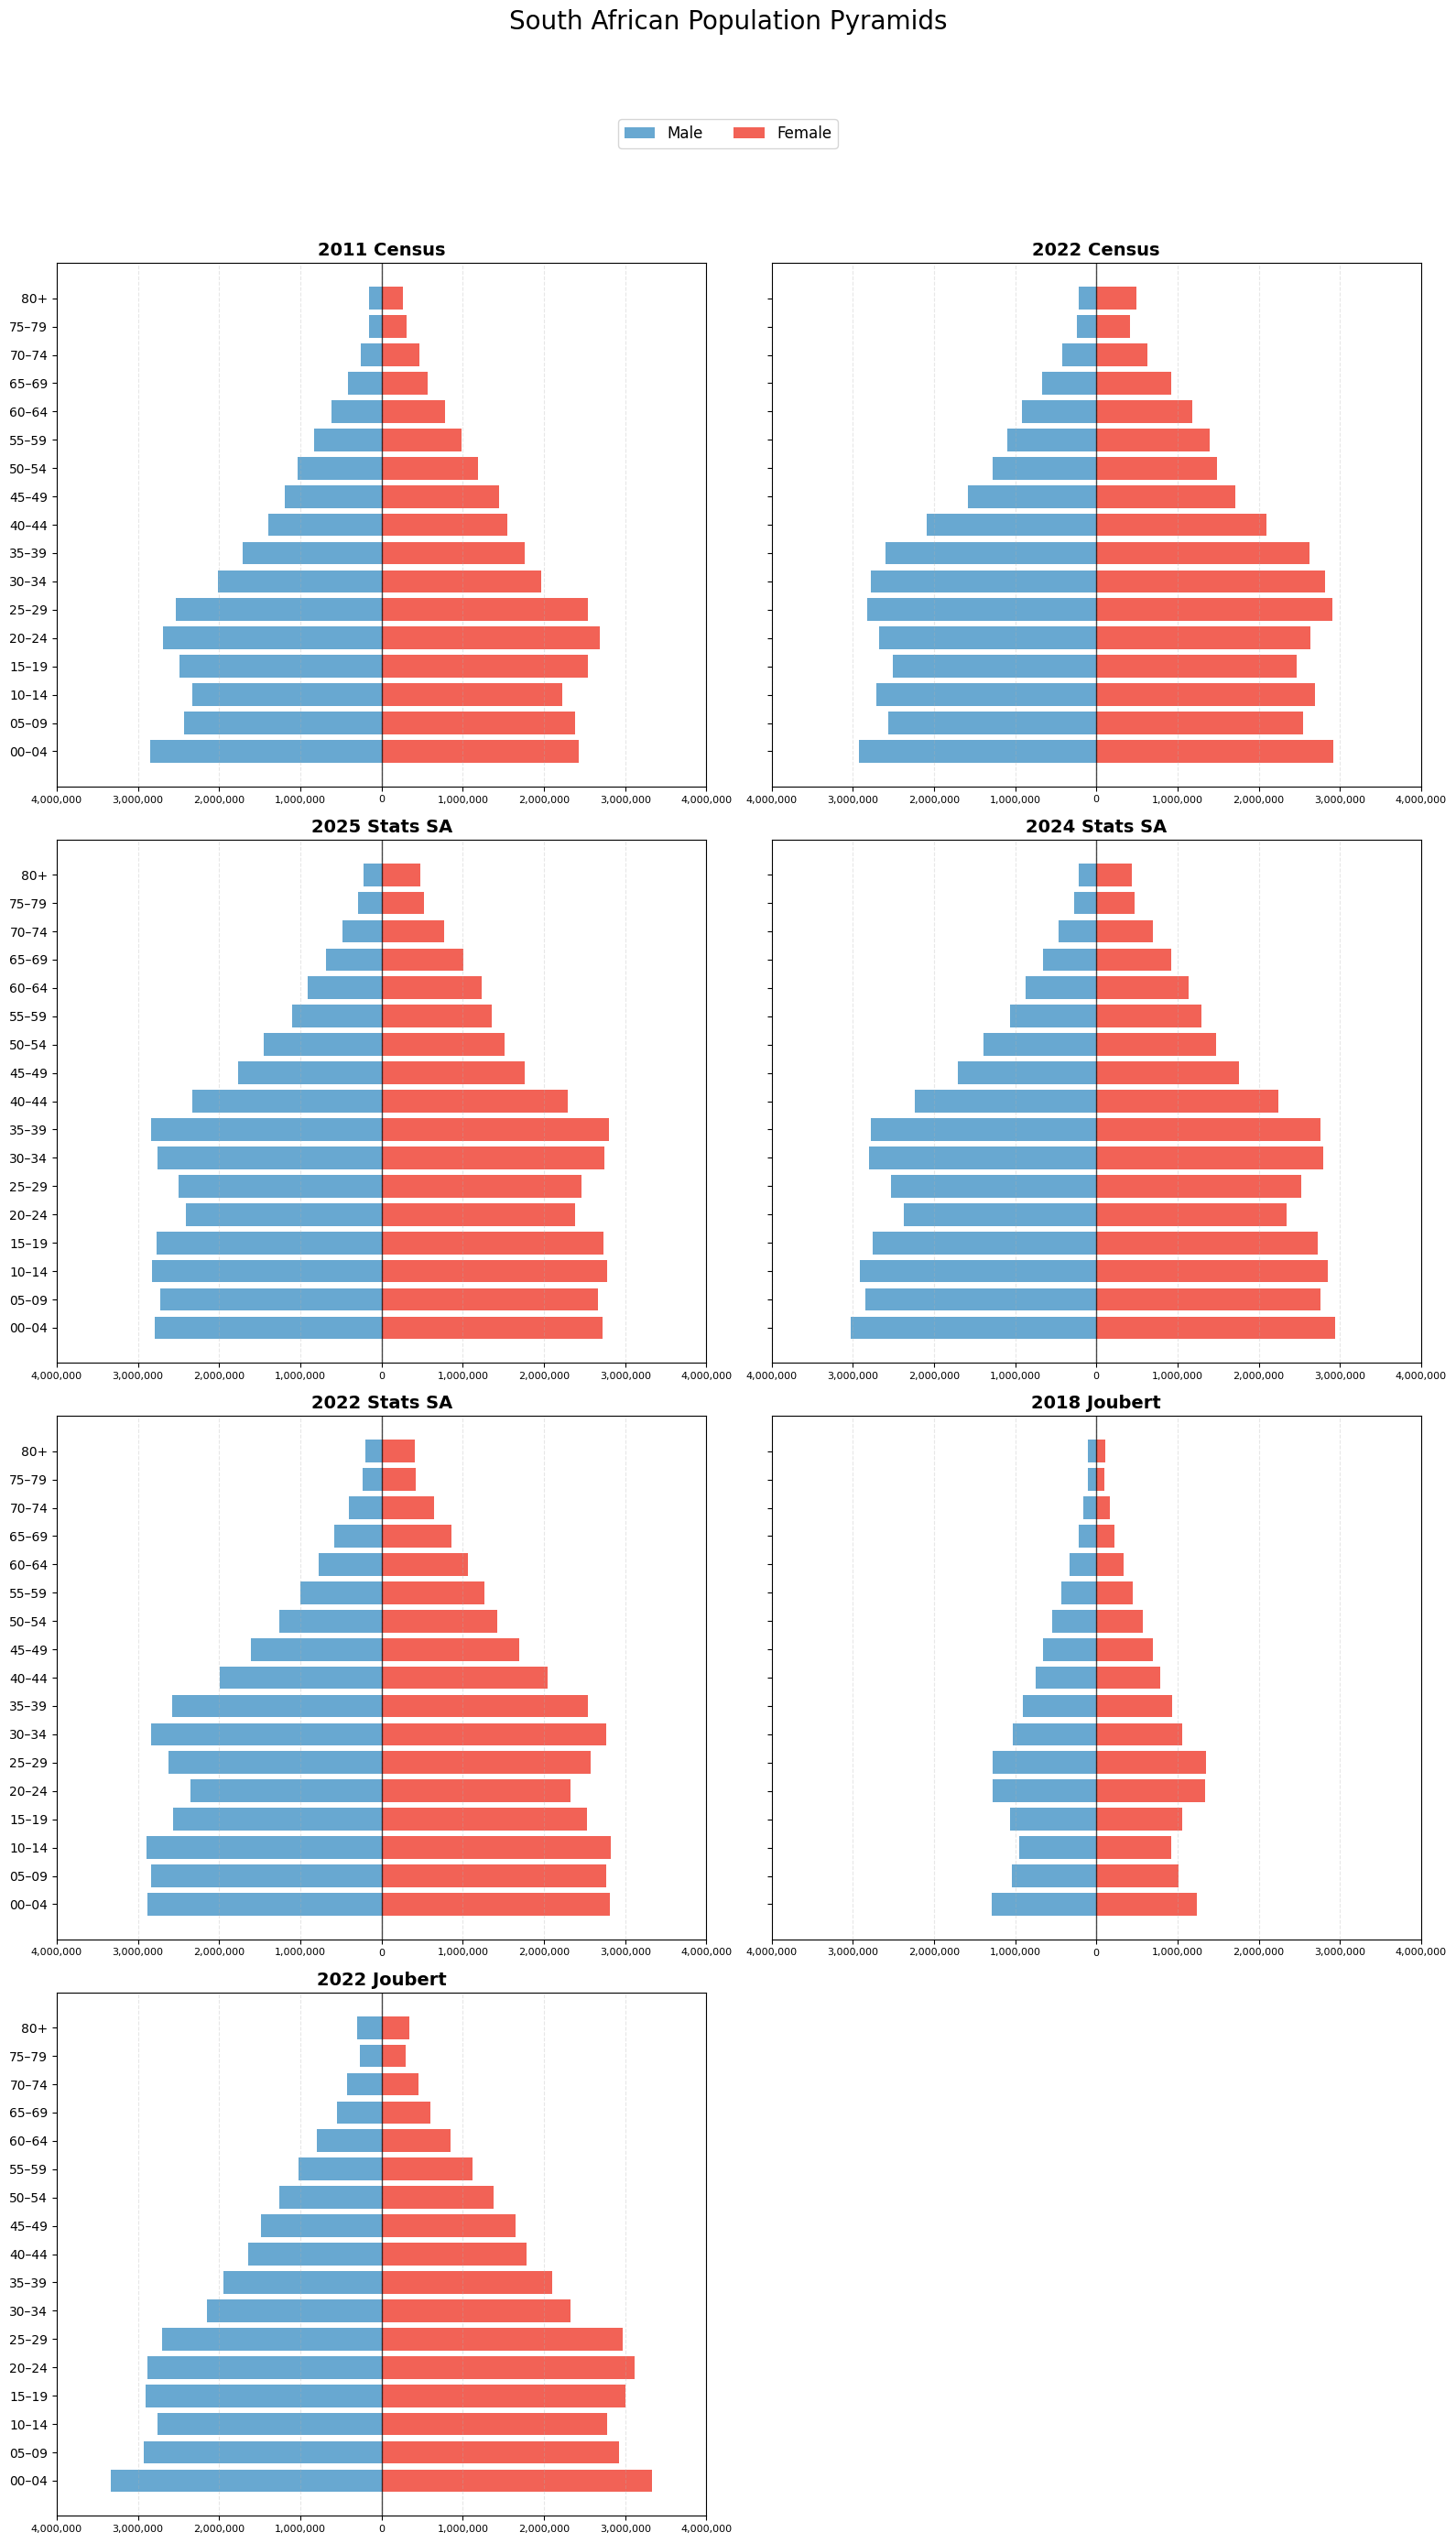

In [6]:
mask = df_age_SA['Sex'].isin(['Male', 'Female'])
global_max = df_age_SA.loc[mask, age_columns].values.max() * 1.1

unique_sources = df_age_SA['Data Source'].unique()
n_datasets = len(unique_sources)
cols = 2
rows = math.ceil(n_datasets / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 7 * rows))
axes = axes.flatten()

for i, source in enumerate(unique_sources):
    ax = axes[i]
    
    # Filter data
    subset = df_age_SA[df_age_SA['Data Source'] == source]
    males = subset[subset['Sex'] == 'Male'][age_columns].values.flatten()
    females = subset[subset['Sex'] == 'Female'][age_columns].values.flatten()

    # Draw bars
    ax.barh(age_columns, -males, color='#4292c6', label='Male', alpha=0.8)
    ax.barh(age_columns, females, color='#ef3b2c', label='Female', alpha=0.8)

    # Set the X-axis limit to be identical and centered on 0
    ax.set_xlim(-global_max, global_max)
    
    ax.set_title(source, fontsize=14, fontweight='bold')
    
    # Clean up X-axis to show positive numbers on both sides
    ticks = ax.get_xticks()
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{abs(x):,.0f}' for x in ticks], fontsize=8)
    
    # Draw a vertical line at 0 to anchor the middle
    ax.axvline(0, color='black', linewidth=1, alpha=0.7)
    
    # Only show Y-axis labels (Age Groups) on the leftmost plots
    if i % cols != 0:
        ax.set_yticklabels([])
    
    ax.grid(axis='x', linestyle='--', alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=12, bbox_to_anchor=(0.5, 0.98))

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('South African Population Pyramids', fontsize=20, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 

#plt.savefig("Graphs/SAPopulation_Pyramids.pdf", dpi=300, bbox_inches='tight')
plt.show()

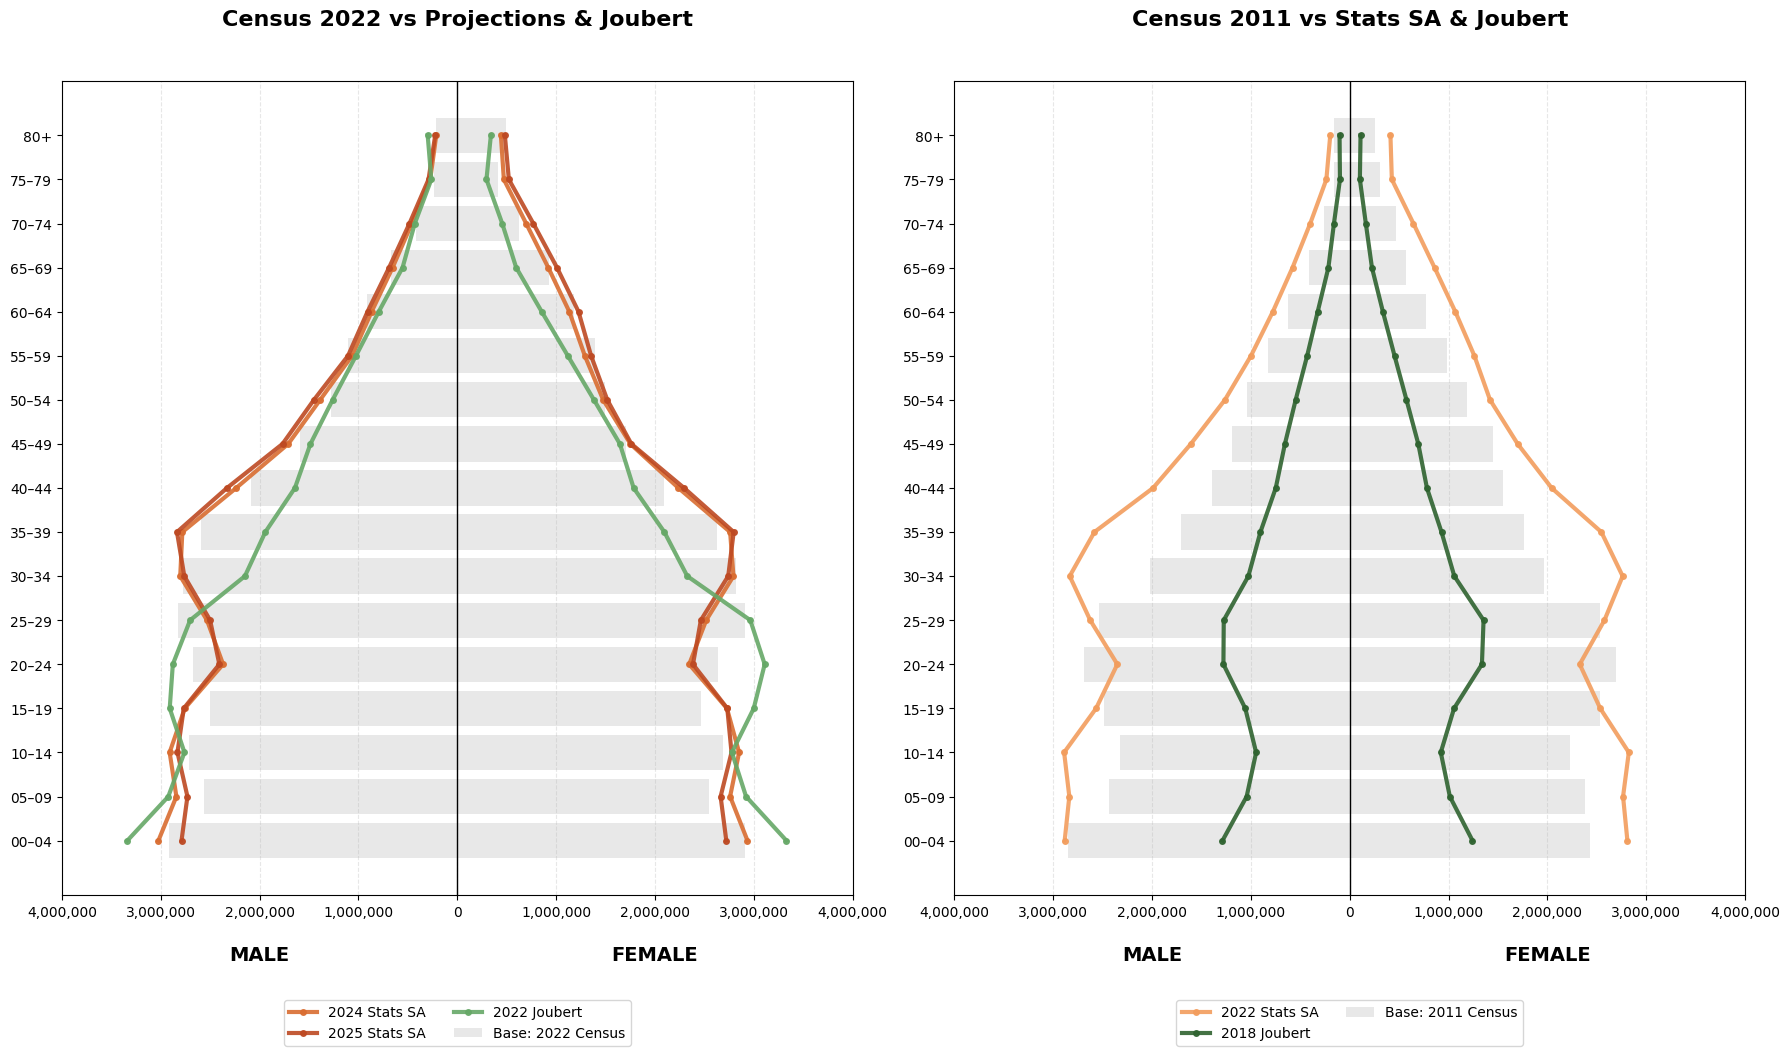

In [7]:
groups = {
    "Census 2022 vs Projections & Joubert": ("2022 Census", ["2024 Stats SA", "2025 Stats SA", "2022 Joubert"]),
    "Census 2011 vs Stats SA & Joubert": ("2011 Census", ["2022 Stats SA", "2018 Joubert"])}

fig, axes = plt.subplots(1, 2, figsize=(18, 12))

for i, (title, (base_name, overlays)) in enumerate(groups.items()):
    ax = axes[i]
    
    # --- Plot Base (Grey Bars) ---
    m_base = df_age_SA[(df_age_SA['Data Source'] == base_name) & (df_age_SA['Sex'] == 'Male')]
    f_base = df_age_SA[(df_age_SA['Data Source'] == base_name) & (df_age_SA['Sex'] == 'Female')]

    if not m_base.empty and not f_base.empty:
        m_vals = pd.to_numeric(m_base[age_columns].iloc[0], errors='coerce').fillna(0)
        f_vals = pd.to_numeric(f_base[age_columns].iloc[0], errors='coerce').fillna(0)
        ax.barh(age_columns, -m_vals, color='#D3D3D3', alpha=0.5, label=f"Base: {base_name}")
        ax.barh(age_columns, f_vals, color='#D3D3D3', alpha=0.5)
    else:
        print(f"FAILED TO FIND BASE: '{base_name}'")

    # --- Plot ALL Overlays ---
    for over_name in overlays:
        # Filter with a bit of flexibility on naming
        m_over = df_age_SA[(df_age_SA['Data Source'].str.strip() == over_name.strip()) & (df_age_SA['Sex'] == 'Male')]
        f_over = df_age_SA[(df_age_SA['Data Source'].str.strip() == over_name.strip()) & (df_age_SA['Sex'] == 'Female')]
        
        if not m_over.empty and not f_over.empty:
            mo_vals = pd.to_numeric(m_over[age_columns].iloc[0], errors='coerce').fillna(0)
            fo_vals = pd.to_numeric(f_over[age_columns].iloc[0], errors='coerce').fillna(0)
            
            color = colour_map.get(over_name, 'black')
            ax.plot(-mo_vals, age_columns, color=color, linewidth=3, label=over_name, marker='o', markersize=4, alpha=0.9)
            ax.plot(fo_vals, age_columns, color=color, linewidth=3, marker='o', markersize=4, alpha=0.9)
        else:
            # This will tell you exactly which one is failing to load
            print(f"FAILED TO FIND OVERLAY: '{over_name}'")

    # Formatting
    ax.set_title(title, fontsize=16, fontweight='bold', pad=40)
    ax.axvline(0, color='black', lw=1)
    
    # Move Male/Female labels to the BOTTOM
    ax.text(0.25, -0.08, 'MALE', transform=ax.transAxes, fontsize=14, fontweight='bold', ha='center')
    ax.text(0.75, -0.08, 'FEMALE', transform=ax.transAxes, fontsize=14, fontweight='bold', ha='center')
    
    # Absolute values for X-axis
    ticks = ax.get_xticks()
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{abs(x):,.0f}' for x in ticks], fontsize=10)
    
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    # Put legend outside to avoid obscuring the lines
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
#plt.savefig("Graphs/Census_Comparison_Pyramids_Fixed.pdf", bbox_inches='tight')
plt.show()

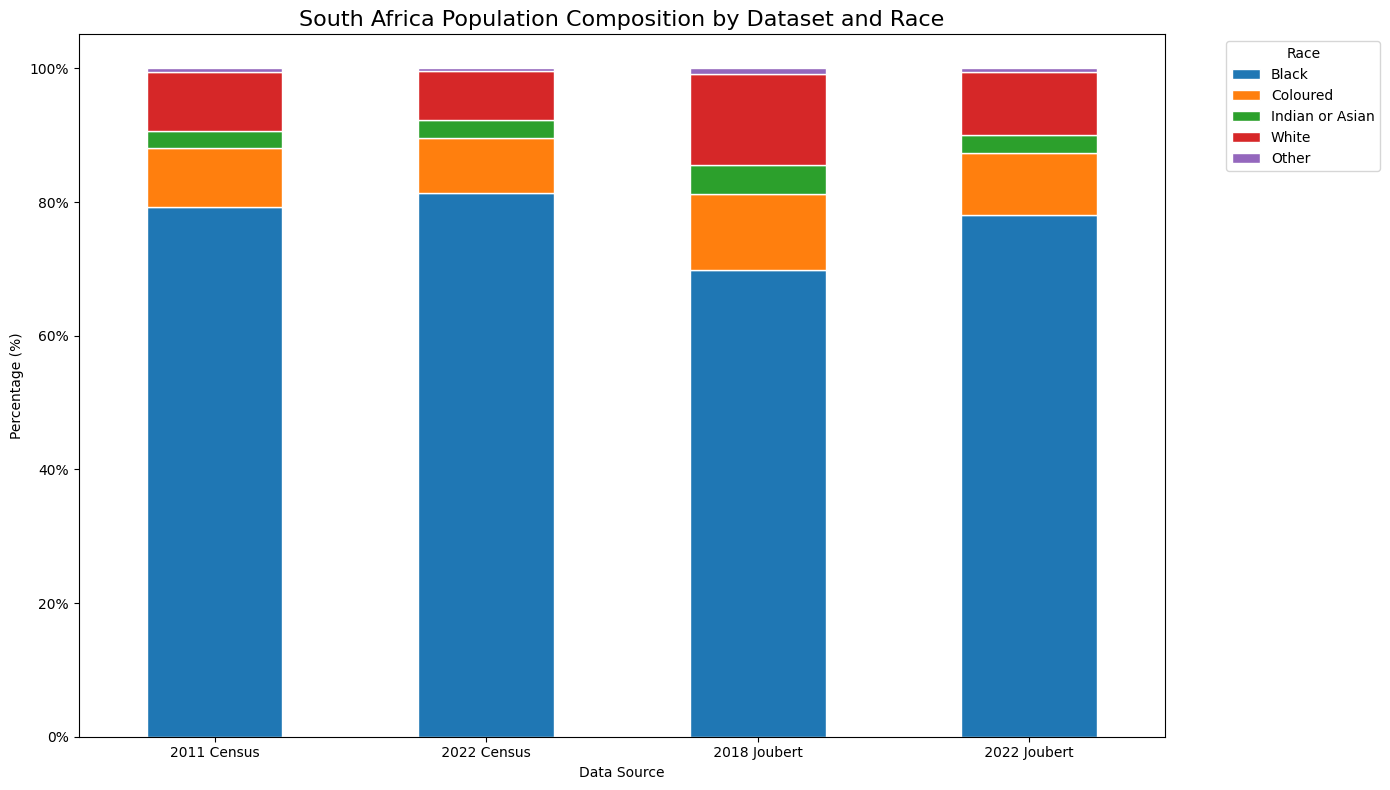

In [16]:
df_plot_SA = df_race_SA.set_index('Data Source')

ax_sa = df_plot_SA.plot(kind='bar', stacked=True, figsize=(14, 8), edgecolor='white')
ax_sa.set_title('South Africa Population Composition by Dataset and Race', fontsize=16)
ax_sa.set_ylabel('Percentage (%)')
ax_sa.yaxis.set_major_formatter(mtick.PercentFormatter()) 
plt.legend(title="Race", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
#plt.savefig("Graphs/SA_Race_Composition.pdf", bbox_inches='tight')
plt.show()

### Provincial Plots

#### Western Cape

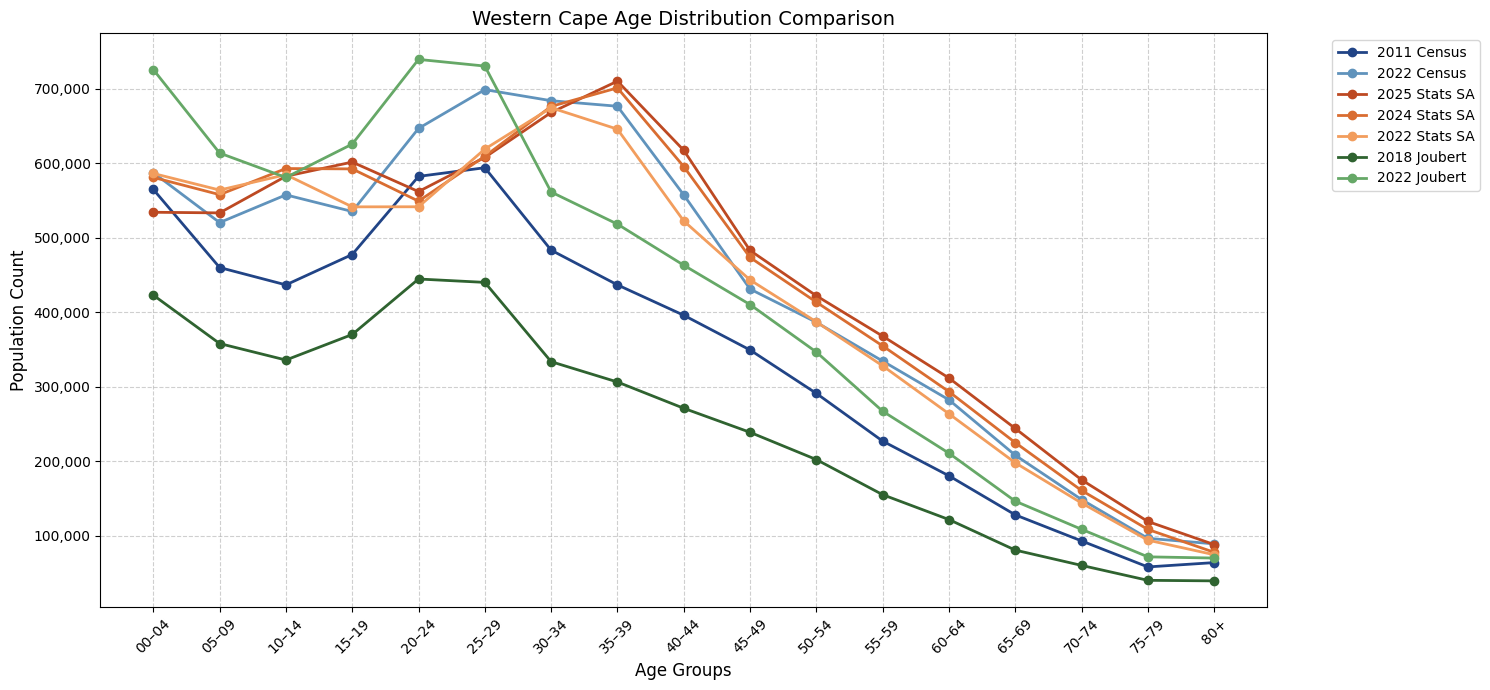

In [9]:
plt.figure(figsize=(15, 7))

for index, row in df_numbers_WC.iterrows():
    label = str(row['Demographic'].strip())
    plt.plot(age_columns, row[age_columns], label=label, 
             color=colour_map.get(label, 'black'), marker='o', linewidth=2)

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.title('Western Cape Age Distribution Comparison', fontsize=14)
plt.xlabel('Age Groups', fontsize=12)
plt.ylabel('Population Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#plt.savefig("Graphs/WC_age_distribution_comparisons.pdf", dpi=300, bbox_inches='tight')
plt.show()

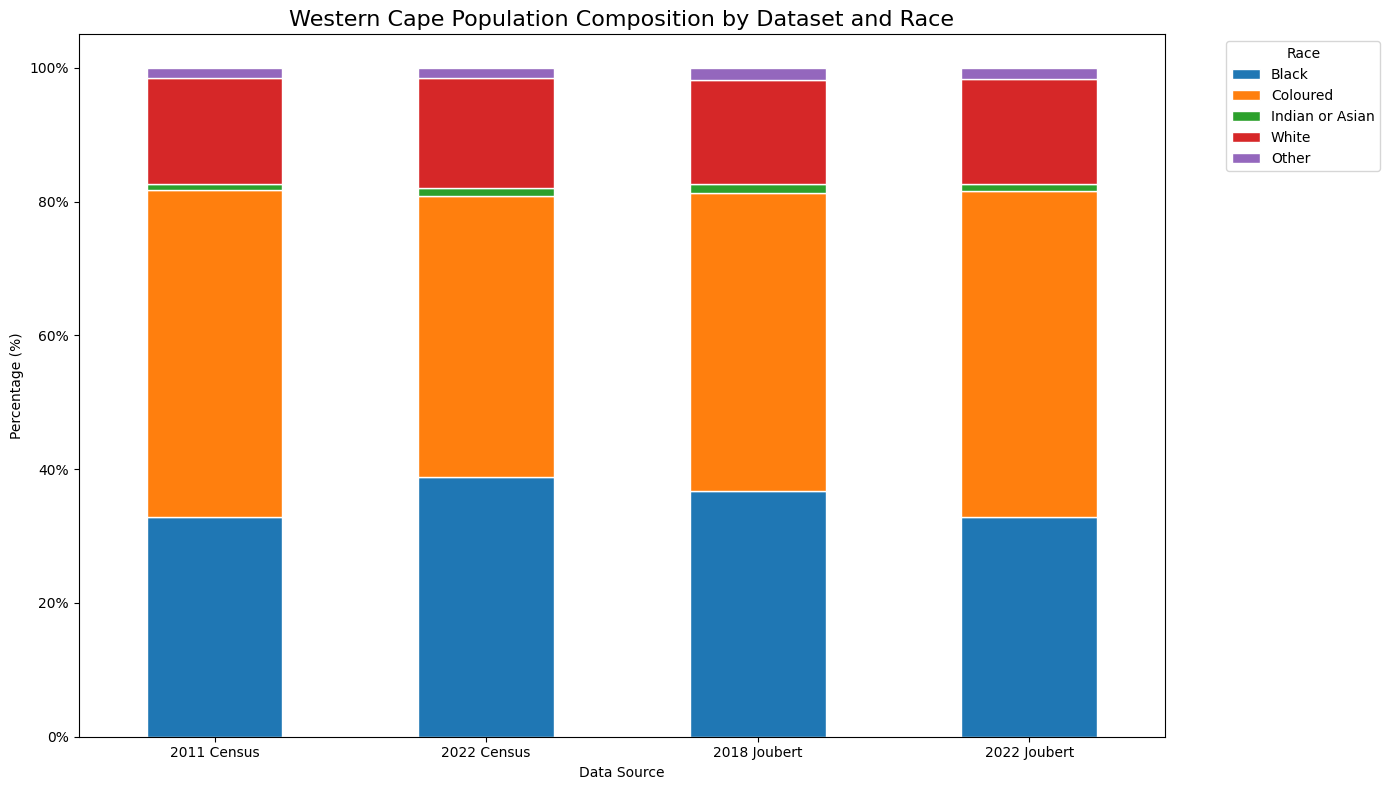

In [14]:
df_plot_WC = df_race_WC.set_index('Data Source')

ax_wc = df_plot_WC.plot(kind='bar', stacked=True, figsize=(14, 8), edgecolor='white')
ax_wc.set_title('Western Cape Population Composition by Dataset and Race', fontsize=16)
ax_wc.set_ylabel('Percentage (%)')
ax_wc.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.legend(title="Race", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
#plt.savefig("Graphs/WC_Race_Composition.pdf", bbox_inches='tight')
plt.show()

#### Gauteng

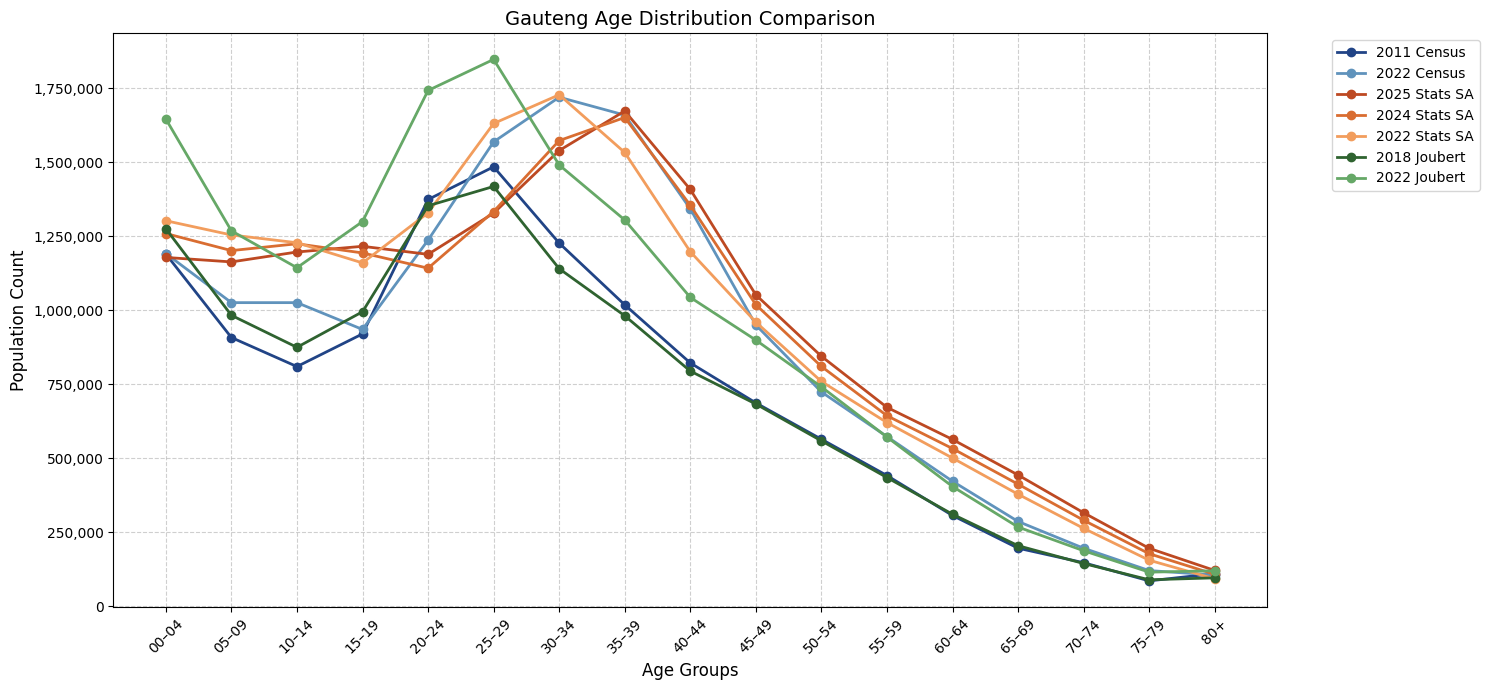

In [11]:
plt.figure(figsize=(15, 7))

for index, row in df_numbers_GP.iterrows():
    label = str(row['Demographic'].strip())
    plt.plot(age_columns, row[age_columns], label=label, 
             color=colour_map.get(label, 'black'), marker='o', linewidth=2)

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.title('Gauteng Age Distribution Comparison', fontsize=14)
plt.xlabel('Age Groups', fontsize=12)
plt.ylabel('Population Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
#plt.savefig("Graphs/GP_age_distribution_comparisons.pdf", dpi=300, bbox_inches='tight')
plt.show()

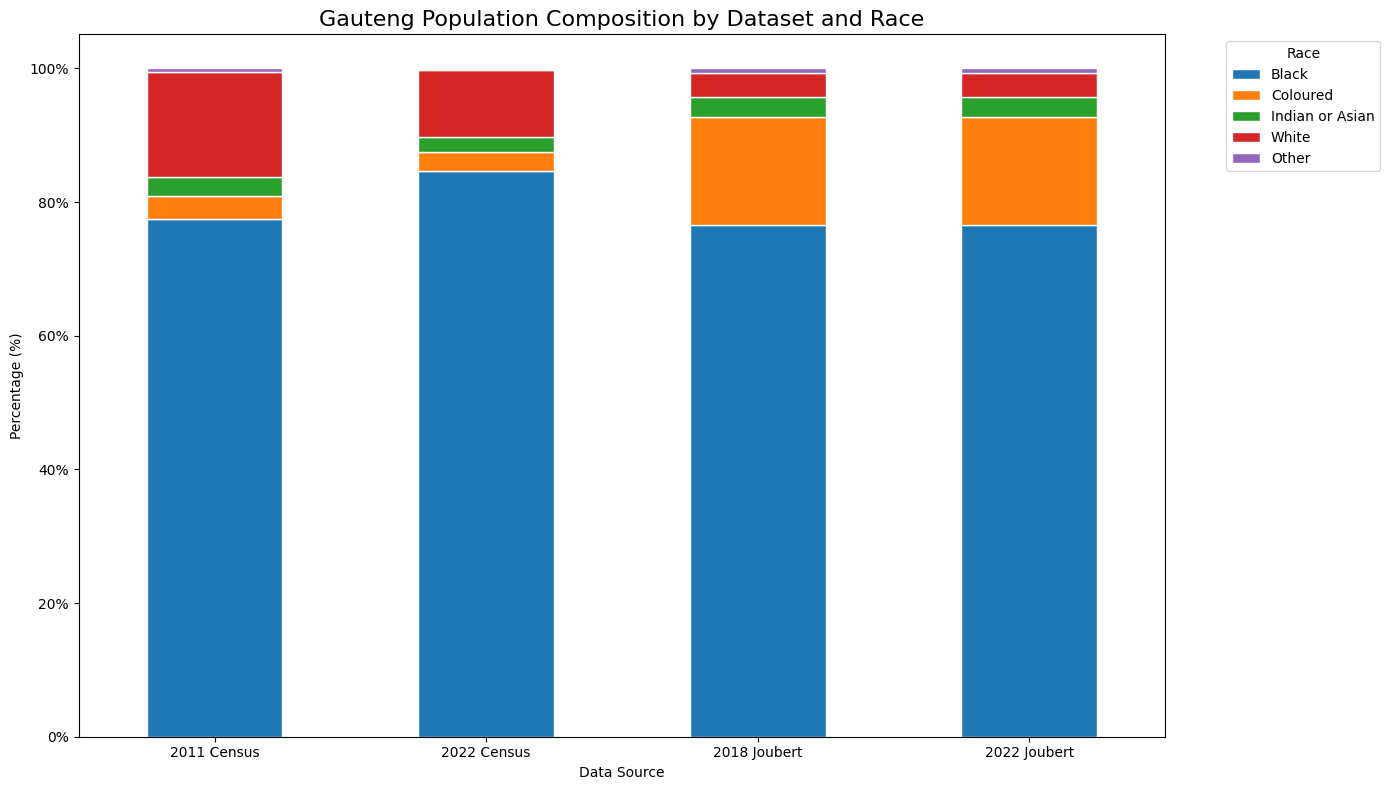

In [17]:
df_plot_GP = df_race_GP.set_index('Data Source')

ax_gp = df_plot_GP.plot(kind='bar', stacked=True, figsize=(14, 8), edgecolor='white')
ax_gp.set_title('Gauteng Population Composition by Dataset and Race', fontsize=16)
ax_gp.set_ylabel('Percentage (%)')
ax_gp.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.legend(title="Race", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
#plt.savefig("Graphs/GP_Race_Composition.pdf", bbox_inches='tight')
plt.show()